### Section 1: Environment Setup

In [1]:
import pandas as pd
import numpy as np
import talib
import pynance as pn
import matplotlib.pyplot as plt
from pathlib import Path

# Setup paths
DATA_DIR = Path('../data/raw/yfinance_data/Data')
SAVE_DIR = Path('../data/processed')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

STOCKS = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']

#### 1.2 Data Loading
Loading the datasets and ensuring types are correct for financial analysis.

In [2]:
stock_dfs = {}

for ticker in STOCKS:
    df = pd.read_csv(DATA_DIR / f"{ticker}.csv")
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    
    # Handle missing values (Forward fill is best for price data)
    df = df.ffill().dropna()
    stock_dfs[ticker] = df

print(f"Successfully loaded {len(stock_dfs)} stocks.")

Successfully loaded 5 stocks.


#### TA-Lib Indicators
Computing Technical Indicators
We use TA-Lib to calculate Moving Averages (SMA/EMA), RSI, and MACD.

In [3]:
for ticker, df in stock_dfs.items():
    close = df['Close'].values
    
    # Moving Averages
    df['SMA_20'] = talib.SMA(close, timeperiod=20)
    df['EMA_20'] = talib.EMA(close, timeperiod=20)
    
    # RSI
    df['RSI_14'] = talib.RSI(close, timeperiod=14)
    
    # MACD
    macd, macdsignal, macdhist = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
    df['MACD'], df['MACD_Signal'], df['MACD_Hist'] = macd, macdsignal, macdhist

#### Markdown - PyNance Metrics
PyNance Financial Metrics
Computing additional daily returns and volatility using the PyNance library.

In [8]:
# Updated Cell 8
for ticker, df in stock_dfs.items():
    # We tell pynance to use 'Close' specifically for the selection
    # This prevents it from looking for the missing 'Adj Close' column
    returns_df = pn.tech.ret(df[['Close']], selection='Close')
    
    # Rename the column in the result so it matches our main DataFrame
    df['Daily_Return'] = returns_df['Return']
    
    # Fill the first row (which is NaN because there's no previous day to compare to)
    df['Daily_Return'] = df['Daily_Return'].fillna(0)

print(f" Daily returns calculated for all stocks using the 'Close' column.")

 Daily returns calculated for all stocks using the 'Close' column.


### Visualization
Data Visualization
Creating panels to show Price Action vs Indicators.

C:\Users\HP\AppData\Local\Temp\ipykernel_17104\1686217026.py:2: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  df = stock_dfs[ticker].last('6M') # Plot last 6 months for clarity
C:\Users\HP\AppData\Local\Temp\ipykernel_17104\1686217026.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df = stock_dfs[ticker].last('6M') # Plot last 6 months for clarity


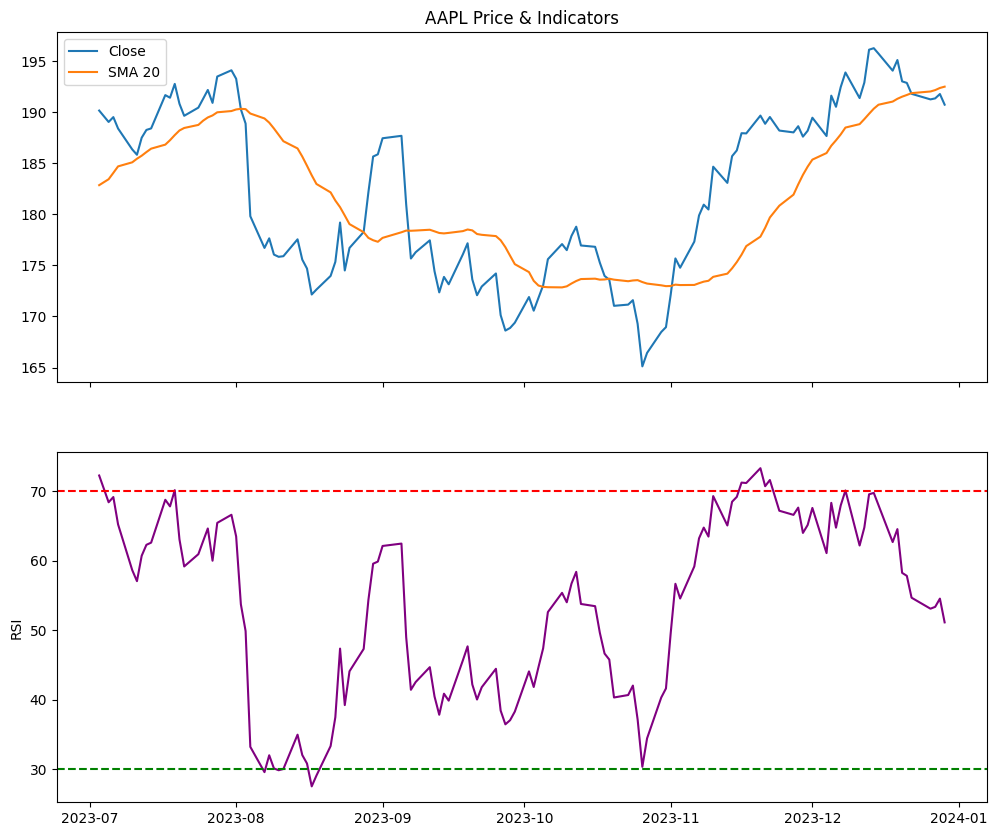

In [9]:
def plot_analysis(ticker):
    df = stock_dfs[ticker].last('6M') # Plot last 6 months for clarity
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Price & Moving Averages
    ax1.plot(df.index, df['Close'], label='Close')
    ax1.plot(df.index, df['SMA_20'], label='SMA 20')
    ax1.set_title(f"{ticker} Price & Indicators")
    ax1.legend()
    
    # RSI
    ax2.plot(df.index, df['RSI_14'], color='purple')
    ax2.axhline(70, color='r', ls='--')
    ax2.axhline(30, color='g', ls='--')
    ax2.set_ylabel('RSI')
    
    plt.show()

plot_analysis('AAPL')

In [10]:
for ticker, df in stock_dfs.items():
    df.to_csv(SAVE_DIR / f"{ticker}_indicators.csv")

Interpretation of Indicators

Insights & Market Behavior
Moving Averages: Crossovers between Price and SMA/EMA suggest potential entry or exit points.

RSI: Values above 70 indicate an overbought condition (potential pullback), while values below 30 indicate an oversold condition (potential bounce).

MACD: The histogram shows the strength of the current trend; crossovers of the Signal line indicate momentum shifts.